# Hardened Classifier & Full Evaluation
## Adversarial Robustness Testing & Trust Safety Pipeline

## Imports

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("All imports successful.")


Device  : cpu
PyTorch : 2.8.0+cpu
All imports successful.


## Configuration

In [3]:
# ── Paths ───────────────────────────────────────────────────
PROJECT_DIR      = Path(r"C:/adversarial_doc_project")
DATA_DIR         = PROJECT_DIR / "data"
SPLITS_DIR       = DATA_DIR / "splits"
AUGMENTED_DIR    = DATA_DIR / "augmented"
OUTPUTS_DIR      = PROJECT_DIR / "outputs"
CHECKPOINTS_DIR  = PROJECT_DIR / "checkpoints"

# ── Training config ──────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 16
NUM_EPOCHS      = 10
LEARNING_RATE   = 1e-4
NUM_CLASSES     = 3
NUM_WORKERS     = 0

CLASS_LIST  = ["real", "benign", "malicious"]
CLASS_NAMES = {0: "real", 1: "benign", 2: "malicious"}

# ── Model paths ──────────────────────────────────────────────
BASELINE_MODEL_PATH  = CHECKPOINTS_DIR / "baseline_efficientnet_best.pth"
HARDENED_EFFNET_PATH = CHECKPOINTS_DIR / "hardened_efficientnet_best.pth"
HARDENED_RESNET_PATH = CHECKPOINTS_DIR / "hardened_resnet18_best.pth"

# Verify augmented data exists
assert (SPLITS_DIR / "aug_train.csv").exists(), "aug_train.csv not found. Run Week 3."
assert BASELINE_MODEL_PATH.exists(), "Baseline model not found. Run Week 2."

print("Configuration ready.")
print(f"Project dir  : {PROJECT_DIR}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Classes      : {CLASS_LIST}")


Configuration ready.
Project dir  : C:\adversarial_doc_project
Batch size   : 16
Epochs       : 10
Classes      : ['real', 'benign', 'malicious']


## Load Augmented Dataset

In [4]:
# Load augmented splits
aug_train = pd.read_csv(SPLITS_DIR / "aug_train.csv")
aug_val   = pd.read_csv(SPLITS_DIR / "aug_val.csv")
aug_test  = pd.read_csv(SPLITS_DIR / "aug_test.csv")

print(f"Train : {len(aug_train)} frames")
print(f"Val   : {len(aug_val)} frames")
print(f"Test  : {len(aug_test)} frames")

print(f"\nClass distribution in train:")
print(aug_train["label_name"].value_counts().to_string())

# Verify a sample path
sample = aug_train["frame_path"].iloc[0]
assert Path(sample).exists(), f"Frame not found: {sample}"
print(f"\nSample path verified: {sample}")


Train : 14700 frames
Val   : 3150 frames
Test  : 3150 frames

Class distribution in train:
label_name
real         4900
benign       4900
malicious    4900

Sample path verified: C:\adversarial_doc_project\data\augmented\real\midv2019_videos_DG01_mp4_frame00000_real.jpg


## Build Dataset and Dataloaders

In [8]:
class DocumentDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        img   = Image.open(row["frame_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = DocumentDataset(aug_train, transform=train_transform)
val_dataset   = DocumentDataset(aug_val,   transform=val_transform)
test_dataset  = DocumentDataset(aug_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch shape   : {imgs.shape}")
print(f"Label sample  : {labels[:8].tolist()}")
print("Dataloaders ready.")


Train batches : 919
Val batches   : 197
Test batches  : 197

Batch shape   : torch.Size([16, 3, 224, 224])
Label sample  : [2, 1, 0, 0, 2, 1, 2, 1]
Dataloaders ready.


## Build Models

In [9]:
def build_efficientnet(num_classes=3, pretrained=True):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features, num_classes)
    return model


def build_resnet18(num_classes=3, pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# Build both models
effnet  = build_efficientnet(num_classes=NUM_CLASSES).to(DEVICE)
resnet  = build_resnet18(num_classes=NUM_CLASSES).to(DEVICE)

effnet_params = sum(p.numel() for p in effnet.parameters())
resnet_params = sum(p.numel() for p in resnet.parameters())

print("Models ready:")
print(f"  EfficientNet-B0 : {effnet_params:,} parameters")
print(f"  ResNet18        : {resnet_params:,} parameters")

# Sanity check
with torch.no_grad():
    x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print(f"\nEfficientNet output shape : {effnet(x).shape}")
    print(f"ResNet18 output shape     : {resnet(x).shape}")


Models ready:
  EfficientNet-B0 : 4,011,391 parameters
  ResNet18        : 11,178,051 parameters

EfficientNet output shape : torch.Size([2, 3])
ResNet18 output shape     : torch.Size([2, 3])


## Training Functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total   = 0
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item()
            preds = out.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels


def train_model(model, model_name, save_path, num_epochs=10):
    """Full training loop with early stopping and checkpoint saving."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    print(f"\nTraining {model_name}...")
    print("-" * 65)
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
    print("-" * 65)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl_loss, vl_acc, vl_preds, vl_labels = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_acc"    : vl_acc,
            }, save_path)
            tag = " ← best"
        else:
            tag = ""

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.4f} | "
              f"{vl_loss:>8.4f} | {vl_acc:>6.4f}{tag}")

    print("-" * 65)
    print(f"Best val accuracy: {best_val_acc:.4f}")
    print(f"Model saved: {save_path}")
    return history, best_val_acc


print("Training functions defined.")


Training functions defined.


## Train Hardened EfficientNet-B0

In [11]:
effnet_history, effnet_best_acc = train_model(
    model      = effnet,
    model_name = "Hardened EfficientNet-B0",
    save_path  = HARDENED_EFFNET_PATH,
    num_epochs = NUM_EPOCHS
)



Training Hardened EfficientNet-B0...
-----------------------------------------------------------------
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-----------------------------------------------------------------


     1 |     0.2664 |   0.9092 |   0.1299 | 0.9575 ← best


     2 |     0.1323 |   0.9536 |   0.1068 | 0.9679 ← best


     3 |     0.1013 |   0.9656 |   0.1056 | 0.9638


     4 |     0.0853 |   0.9702 |   0.0772 | 0.9746 ← best


...

     6 |     0.0527 |   0.9821 |   0.0709 | 0.9765 ← best


     7 |     0.0442 |   0.9855 |   0.0698 | 0.9781 ← best


     8 |     0.0385 |   0.9871 |   0.0746 | 0.9790 ← best


     9 |     0.0380 |   0.9869 |   0.0670 | 0.9794 ← best


    10 |     0.0344 |   0.9879 |   0.0655 | 0.9819 ← best
-----------------------------------------------------------------
Best val accuracy: 0.9819
Model saved: C:\adversarial_doc_project\checkpoints\hardened_efficientnet_best.pth


## Train Hardened ResNet18


In [12]:
resnet_history, resnet_best_acc = train_model(
    model      = resnet,
    model_name = "Hardened ResNet18",
    save_path  = HARDENED_RESNET_PATH,
    num_epochs = NUM_EPOCHS
)



Training Hardened ResNet18...
-----------------------------------------------------------------
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-----------------------------------------------------------------


     1 |     0.2275 |   0.9152 |   0.2107 | 0.9238 ← best


     2 |     0.1448 |   0.9472 |   0.1166 | 0.9584 ← best


     3 |     0.1103 |   0.9620 |   0.1014 | 0.9702 ← best


     4 |     0.0990 |   0.9661 |   0.1098 | 0.9619


...

     6 |     0.0601 |   0.9792 |   0.0809 | 0.9771 ← best


     7 |     0.0477 |   0.9824 |   0.0961 | 0.9702


     8 |     0.0469 |   0.9837 |   0.0708 | 0.9803 ← best


     9 |     0.0453 |   0.9842 |   0.0796 | 0.9781


    10 |     0.0459 |   0.9837 |   0.0886 | 0.9775
-----------------------------------------------------------------
Best val accuracy: 0.9803
Model saved: C:\adversarial_doc_project\checkpoints\hardened_resnet18_best.pth


## Plot Training Curves

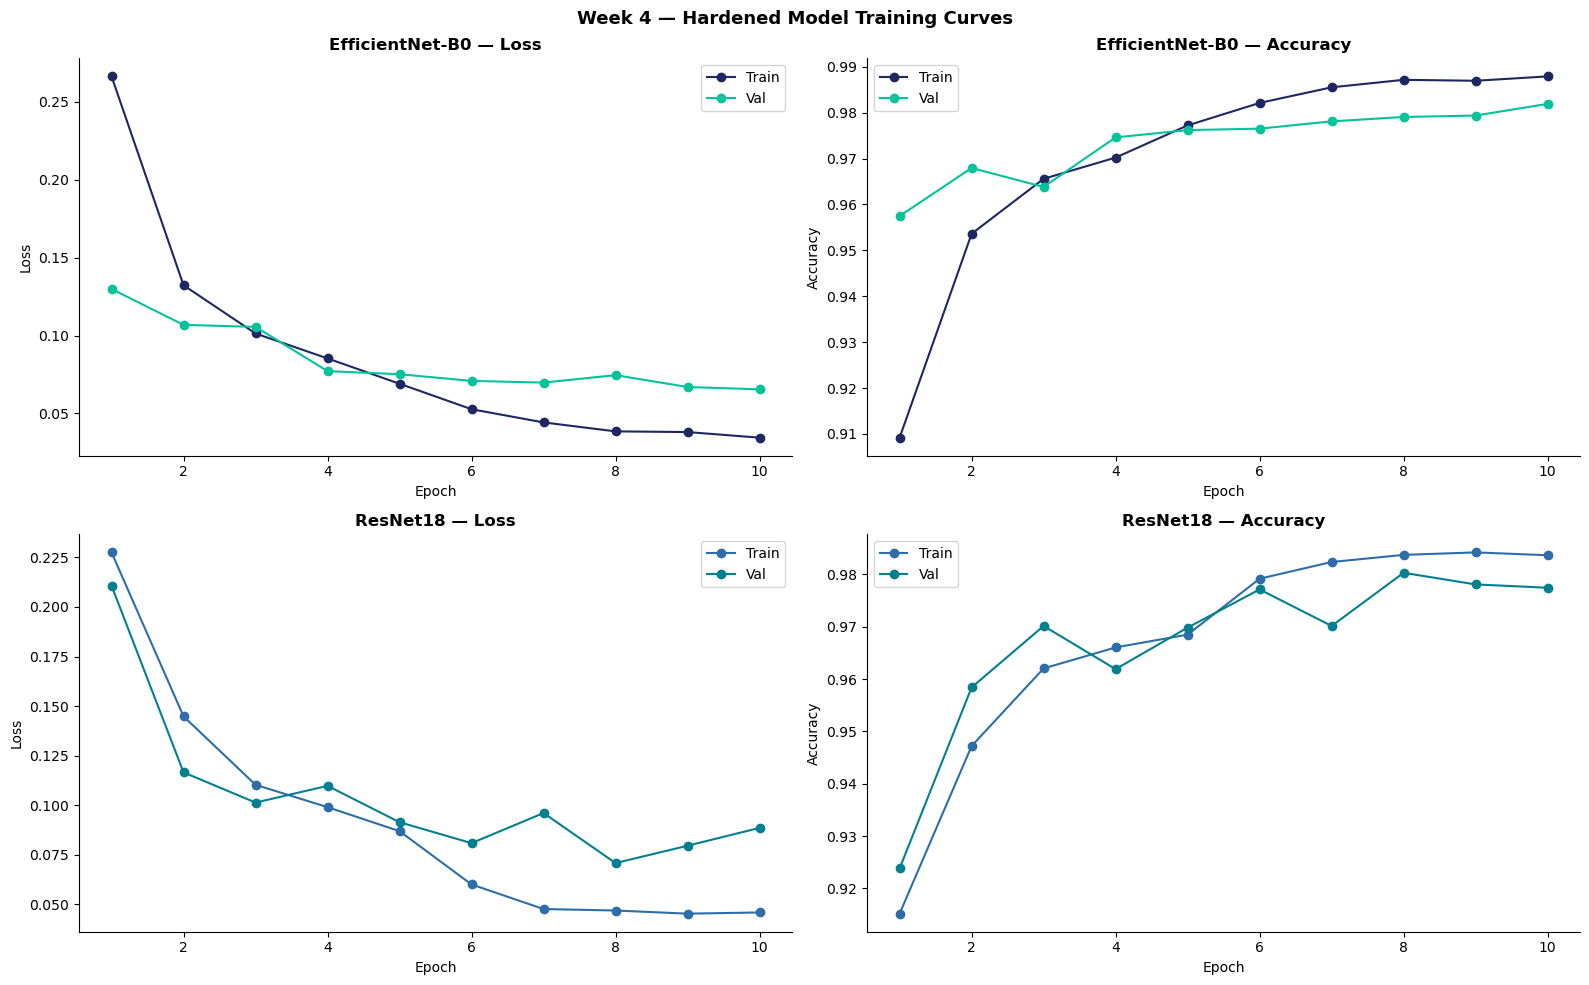

Training curves saved: C:\adversarial_doc_project\outputs\week4_training_curves.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Week 4 — Hardened Model Training Curves", fontsize=13, fontweight="bold")

epochs = range(1, NUM_EPOCHS + 1)
configs = [
    (effnet_history, "EfficientNet-B0", "#1E2761", "#02C39A"),
    (resnet_history, "ResNet18",        "#2D6EA8", "#028090"),
]

for row, (history, name, c1, c2) in enumerate(configs):
    # Loss
    ax = axes[row][0]
    ax.plot(epochs, history["train_loss"], color=c1, marker="o", label="Train")
    ax.plot(epochs, history["val_loss"],   color=c2, marker="o", label="Val")
    ax.set_title(f"{name} — Loss", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

    # Accuracy
    ax = axes[row][1]
    ax.plot(epochs, history["train_acc"], color=c1, marker="o", label="Train")
    ax.plot(epochs, history["val_acc"],   color=c2, marker="o", label="Val")
    ax.set_title(f"{name} — Accuracy", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = OUTPUTS_DIR / "week4_training_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved: {out}")


## Full Evaluation on Test Set

In [14]:
criterion = nn.CrossEntropyLoss()
results   = {}

for model_obj, model_name, ckpt_path in [
    (effnet, "Hardened EfficientNet-B0", HARDENED_EFFNET_PATH),
    (resnet, "Hardened ResNet18",        HARDENED_RESNET_PATH),
]:
    # Load best checkpoint
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model_obj.load_state_dict(ckpt["model_state"])

    _, test_acc, test_preds, test_labels = evaluate(
        model_obj, test_loader, criterion, DEVICE)

    f1   = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    prec = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
    rec  = recall_score(test_labels, test_preds, average="weighted", zero_division=0)

    results[model_name] = {
        "accuracy"   : round(test_acc, 4),
        "f1"         : round(f1, 4),
        "precision"  : round(prec, 4),
        "recall"     : round(rec, 4),
        "preds"      : test_preds,
        "labels"     : test_labels,
    }

    print(f"\n{'='*55}")
    print(f"{model_name} — TEST SET RESULTS")
    print(f"{'='*55}")
    print(f"  Accuracy  : {test_acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(
        test_labels, test_preds,
        labels=[0,1,2],
        target_names=CLASS_LIST,
        zero_division=0
    ))



Hardened EfficientNet-B0 — TEST SET RESULTS
  Accuracy  : 0.9892
  F1 Score  : 0.9892
  Precision : 0.9894
  Recall    : 0.9892

Per-class report:
              precision    recall  f1-score   support

        real       0.97      1.00      0.98      1050
      benign       1.00      0.97      0.98      1050
   malicious       1.00      1.00      1.00      1050

    accuracy                           0.99      3150
   macro avg       0.99      0.99      0.99      3150
weighted avg       0.99      0.99      0.99      3150




Hardened ResNet18 — TEST SET RESULTS
  Accuracy  : 0.9832
  F1 Score  : 0.9832
  Precision : 0.9832
  Recall    : 0.9832

Per-class report:
              precision    recall  f1-score   support

        real       0.97      0.98      0.98      1050
      benign       0.98      0.97      0.97      1050
   malicious       1.00      1.00      1.00      1050

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150



## Confusion Matrices

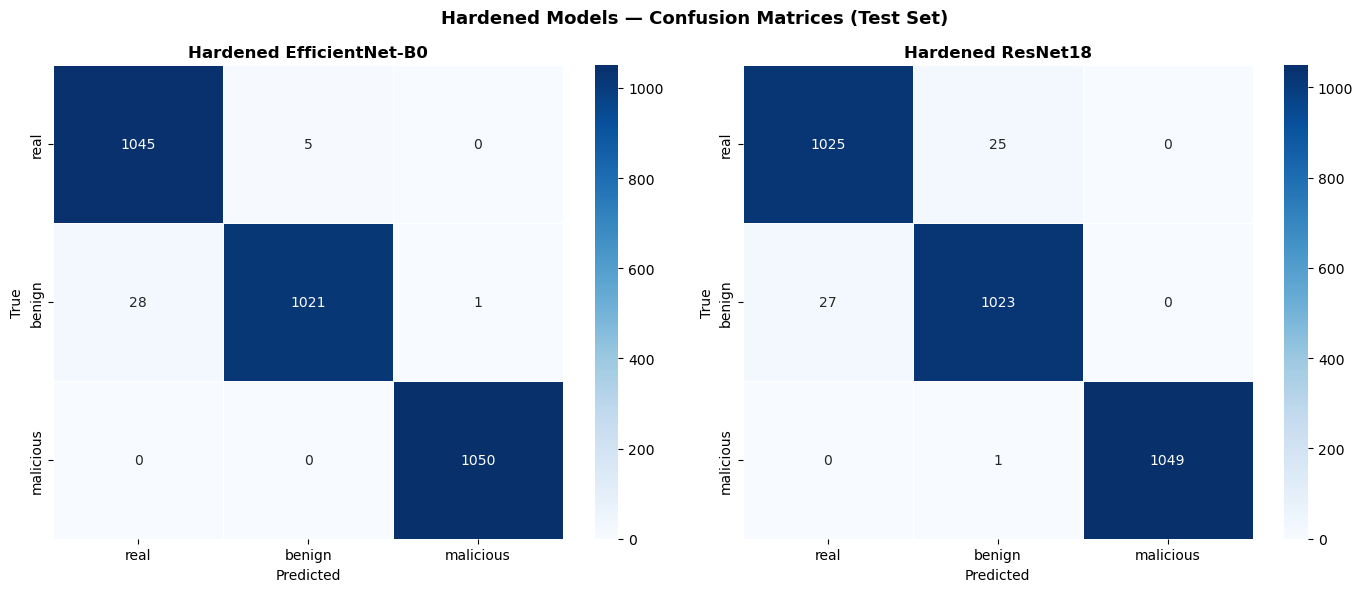

Confusion matrices saved: C:\adversarial_doc_project\outputs\week4_confusion_matrices.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Hardened Models — Confusion Matrices (Test Set)",
             fontsize=13, fontweight="bold")

for ax, (model_name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_LIST,
                yticklabels=CLASS_LIST,
                linewidths=0.5, ax=ax)
    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
out = OUTPUTS_DIR / "week4_confusion_matrices.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrices saved: {out}")


## Baseline vs Hardened Comparison

BASELINE vs HARDENED — COMPARISON TABLE
                   Model  F1 Score  Accuracy
       Baseline (Week 2)    0.1826    0.3400
Hardened EfficientNet-B0    0.9892    0.9892
       Hardened ResNet18    0.9832    0.9832


C:\Users\chaar\AppData\Local\Temp\ipykernel_29652\3599310971.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(comp_df["Model"], rotation=10, ha="right")
C:\Users\chaar\AppData\Local\Temp\ipykernel_29652\3599310971.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(comp_df["Model"], rotation=10, ha="right")


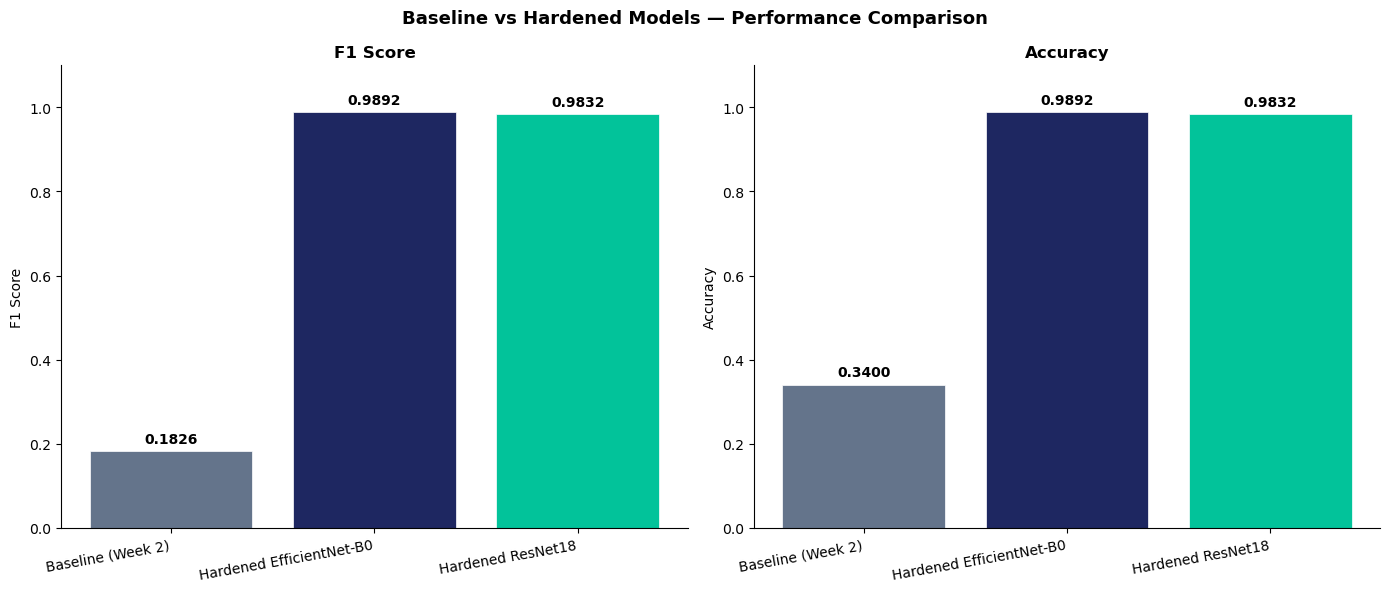

Comparison plot saved: C:\adversarial_doc_project\outputs\week4_comparison.png

F1 improvement from hardening: +0.8066
(0.1826 → 0.9892)


In [16]:
# Baseline pre-hardening F1 from Week 3
BASELINE_F1 = 0.1826

comparison = {
    "Model"             : ["Baseline (Week 2)", "Hardened EfficientNet-B0", "Hardened ResNet18"],
    "F1 Score"          : [BASELINE_F1,
                           results["Hardened EfficientNet-B0"]["f1"],
                           results["Hardened ResNet18"]["f1"]],
    "Accuracy"          : [0.34,
                           results["Hardened EfficientNet-B0"]["accuracy"],
                           results["Hardened ResNet18"]["accuracy"]],
}
comp_df = pd.DataFrame(comparison)

print("=" * 55)
print("BASELINE vs HARDENED — COMPARISON TABLE")
print("=" * 55)
print(comp_df.to_string(index=False))
print("=" * 55)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Baseline vs Hardened Models — Performance Comparison",
             fontsize=13, fontweight="bold")

colors = ["#64748B", "#1E2761", "#02C39A"]

for ax, metric in zip(axes, ["F1 Score", "Accuracy"]):
    bars = ax.bar(comp_df["Model"], comp_df[metric],
                  color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(comp_df["Model"], rotation=10, ha="right")
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = OUTPUTS_DIR / "week4_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Comparison plot saved: {out}")

# Print improvement
best_hardened_f1 = max(results["Hardened EfficientNet-B0"]["f1"],
                       results["Hardened ResNet18"]["f1"])
improvement = best_hardened_f1 - BASELINE_F1
print(f"\nF1 improvement from hardening: +{improvement:.4f}")
print(f"({BASELINE_F1:.4f} → {best_hardened_f1:.4f})")


## GradCAM Visualisations

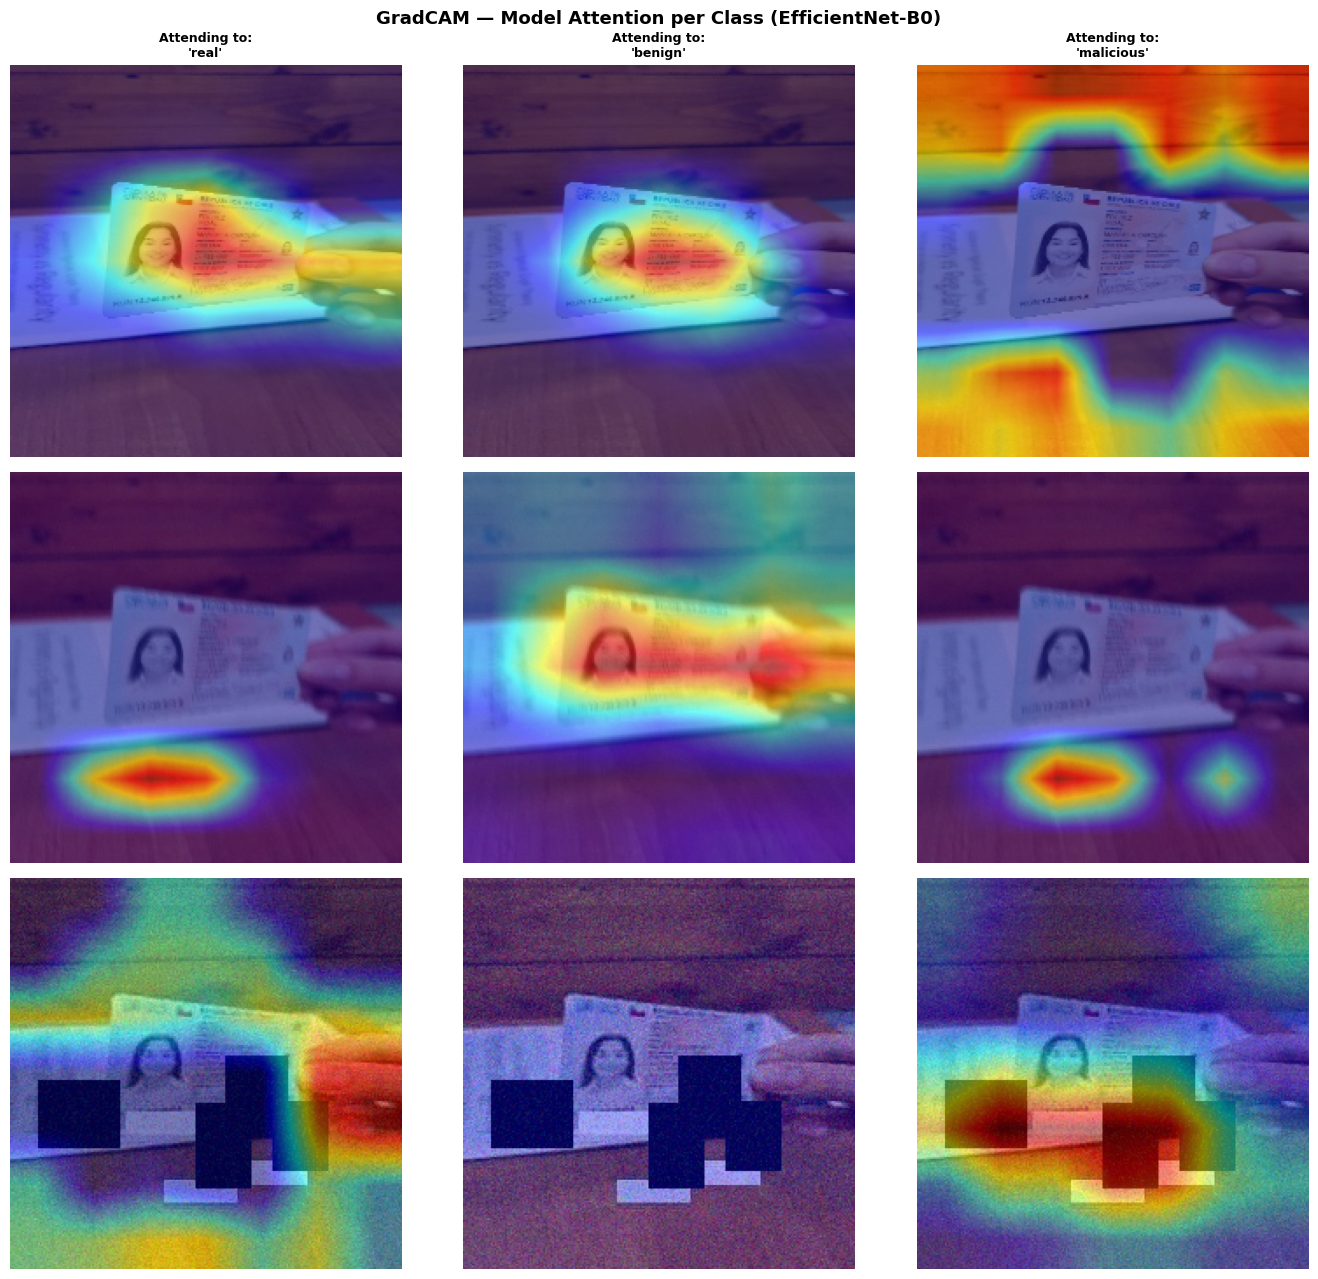

GradCAM visualisations saved: C:\adversarial_doc_project\outputs\week4_gradcam.png


In [17]:
# Load best hardened model (EfficientNet)
ckpt = torch.load(HARDENED_EFFNET_PATH, map_location=DEVICE, weights_only=True)
effnet.load_state_dict(ckpt["model_state"])
effnet.eval()

# GradCAM target layer — last feature block of EfficientNet
target_layers = [effnet.features[-1]]
cam = GradCAM(model=effnet, target_layers=target_layers)

# Get one sample per class from test set
sample_per_class = {}
for _, row in aug_test.iterrows():
    label = int(row["label"])
    if label not in sample_per_class:
        sample_per_class[label] = row["frame_path"]
    if len(sample_per_class) == 3:
        break

# Inverse normalisation for display
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
fig.suptitle("GradCAM — Model Attention per Class (EfficientNet-B0)",
             fontsize=13, fontweight="bold")

row_labels = ["Real Document", "Benign Perturbation", "Malicious Tampering"]

for class_idx in range(3):
    img_path = sample_per_class[class_idx]
    img_pil  = Image.open(img_path).convert("RGB")
    img_np   = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))) / 255.0

    input_tensor = preprocess(img_pil).unsqueeze(0).to(DEVICE)

    # Get GradCAM for all 3 class targets
    for target_class in range(3):
        targets      = [ClassifierOutputTarget(target_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        cam_image    = show_cam_on_image(
            img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)

        ax = axes[class_idx][target_class]
        ax.imshow(cam_image)

        if class_idx == 0:
            ax.set_title(f"Attending to:\n'{CLASS_LIST[target_class]}'",
                         fontweight="bold", fontsize=9)
        if target_class == 0:
            ax.set_ylabel(row_labels[class_idx], fontsize=9, fontweight="bold")
        ax.axis("off")

plt.tight_layout()
out = OUTPUTS_DIR / "week4_gradcam.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"GradCAM visualisations saved: {out}")
